# Car Price Prediction System – 10-Fold Cross Validation (Full Dataset)

## Setup: Running This Notebook on Google Colab

No installation is needed. Google Colab already has every library this notebook uses.

1. Go to **https://colab.research.google.com** and sign in with a Google account.
2. Click **File → Upload notebook** and choose this `.ipynb` file.
3. Click **Runtime → Run all**.
4. When **Step 2.1** runs, a **"Choose Files"** button appears below that cell. Click it and select **`car_price.csv`** from your computer. The notebook continues automatically after the upload.

> **Note:** Colab deletes uploaded files when the runtime is reset or disconnected. If you get a *"file not found"* error, run Step 2.1 again and re-upload `car_price.csv`.

---


## Introduction

##### **Definition** A regression ML task that predicts the price (MSRP) of a car from its specifications, such as engine horsepower, model year, number of cylinders, fuel efficiency and market category.
##### **Application** Car dealership pricing, insurance valuation, used-car marketplaces, rental car pricing and loan collateral assessment.

### Aim of This Notebook

In the previous notebook we trained **one** algorithm (Random Forest) and tested it on **one** train/test split. This notebook answers a different question:

> **Which of 5 regression algorithms predicts car prices best, and how sure can we be about that answer?**

To answer it fairly we use **K-Fold Cross Validation** and compare the algorithms using **Root Mean Squared Error (RMSE)**.

This notebook uses the **full dataset** with **10-fold cross validation**. It has a companion notebook that runs the same experiment on only **100 instances with 3-fold cross validation**. Comparing the two shows how much the amount of data affects both the error and how *reliable* the error estimate is.

### What is K-Fold Cross Validation?

A single train/test split can be lucky or unlucky: the result depends on *which* cars happened to land in the test set. K-Fold Cross Validation removes this luck:

1. Shuffle the data and split it into **K equal parts (folds)**.
2. Train the model on **K−1 folds** and test it on the **remaining fold**.
3. Repeat **K times**, so that **every fold is used as the test set exactly once**.
4. Report the **average** score over the K rounds (and the standard deviation, to show how much it varies).

With **K = 10** on the **full dataset (~11,900 cars)**, each test fold has about 1,120 cars and each training set has about 10,000 cars:

```
Round  1:  [TEST ] | [train] | [train] | [train] | [train] | [train] | [train] | [train] | [train] | [train]
Round  2:  [train] | [TEST ] | [train] | [train] | [train] | [train] | [train] | [train] | [train] | [train]
Round  3:  [train] | [train] | [TEST ] | [train] | [train] | [train] | [train] | [train] | [train] | [train]
Round  4:  [train] | [train] | [train] | [TEST ] | [train] | [train] | [train] | [train] | [train] | [train]
Round  5:  [train] | [train] | [train] | [train] | [TEST ] | [train] | [train] | [train] | [train] | [train]
Round  6:  [train] | [train] | [train] | [train] | [train] | [TEST ] | [train] | [train] | [train] | [train]
Round  7:  [train] | [train] | [train] | [train] | [train] | [train] | [TEST ] | [train] | [train] | [train]
Round  8:  [train] | [train] | [train] | [train] | [train] | [train] | [train] | [TEST ] | [train] | [train]
Round  9:  [train] | [train] | [train] | [train] | [train] | [train] | [train] | [train] | [TEST ] | [train]
Round 10:  [train] | [train] | [train] | [train] | [train] | [train] | [train] | [train] | [train] | [TEST ]
```

Every car is used for testing **exactly once** and for training **K−1 times**.

### Evaluation Measure: Root Mean Squared Error (RMSE)

$$RMSE = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

- $y_i$ = actual price, $\hat{y}_i$ = predicted price, $n$ = number of test cars
- RMSE is in the **same unit as the output (US dollars)**, so it reads as *"on average, predictions are off by about $X"*.
- **Lower RMSE = better model.** Because errors are squared, RMSE penalises **large mistakes** heavily.

## Input and Output

### Input (Features / Attributes)

| Feature              | Description                                | Type        | Possible Values |
|----------------------|--------------------------------------------|-------------|-----------------|
| **Engine HP**        | Horsepower of the engine                   | Numerical   | 55 – 1001 |
| **Year**             | Model year of the car                      | Numerical   | 1990 – 2017 |
| **Engine Cylinders** | Number of cylinders                        | Numerical   | 0, 3, 4, 5, 6, 8, 10, 12, 16 |
| **city mpg**         | City fuel efficiency (miles per gallon)    | Numerical   | 7 – 137 |
| **highway MPG**      | Highway fuel efficiency (miles per gallon) | Numerical   | 12 – 354 |
| **Popularity**       | Brand popularity score                     | Numerical   | 2 – 5657 |
| **Market Category**  | Vehicle market segment                     | Categorical | Luxury, Crossover, Hatchback, Exotic, … |
| **Vehicle Style**    | Body style of the vehicle                  | Categorical | Sedan, Coupe, 4dr SUV, Convertible, … |

### Output (Prediction)

| Output Attribute | Description                               | Data Type |
|------------------|-------------------------------------------|-----------|
| **MSRP**         | Manufacturer's Suggested Retail Price ($) | Numerical |

### Example Records

| Engine HP | Year | Engine Cylinders | city mpg | Market Category | Vehicle Style | MSRP |
|-----------|------|------------------|----------|-----------------|---------------|------|
| 335 | 2011 | 6 | 19 | Factory Tuner, Luxury, High-Performance | Coupe | 46,135 |
| 300 | 2011 | 6 | 19 | Luxury, Performance | Convertible | 40,650 |
| 275 | 2005 | 6 | 13 | (missing) | 4dr SUV | 29,695 |
| 170 | 2016 | 4 | 25 | (missing) | Sedan | 30,495 |
| 620 | 2011 | 12 | 10 | Exotic, Luxury, High-Performance | Coupe | 463,000 |

## Developer & System Information

| **Attribute**                 | **Details** |
|-------------------------------|-------------|
| **Developer Name**            | Mr. Airej Tashfeen, Dr. Rao Muhammad Adeel Nawab |
| **LinkedIn (Airej Tashfeen)** | [Airej Tashfeen](https://www.linkedin.com/in/airejtashfeen) |
| **LinkedIn (Dr. Adeel)**      | [Dr. Rao Muhammad Adeel Nawab](https://www.linkedin.com/in/rao-muhammad-adeel-nawab) |
| **Program Name**              | `car_price_kfold_full_dataset_10fold` |
| **IDE**                       | Google Colab |
| **Programming Language**      | Python 3 |
| **Libraries**                 | NumPy, Pandas, scikit-learn, Matplotlib, Pickle (built-in). Exact versions are printed in Step 1. |
| **Dataset**                   | `car_price.csv` (11,914 cars, 16 attributes) |

### Table of Contents
- **Step 1:** Import Libraries
- **Step 2:** Load Sample Data
  - **Step 2.1:** Upload the Dataset (Google Colab)
  - **Step 2.2:** Read the Dataset
- **Step 3:** Understand and Pre-process Sample Data
  - **Step 3.1:** Understand Sample Data
  - **Step 3.2:** Pre-process Sample Data
- **Step 4:** Feature Extraction
- **Step 5:** Build the Pre-processing Pipeline
- **Step 6:** Define the 5 Regression Algorithms
- **Step 7:** Set Up 10-Fold Cross Validation
  - **Step 7.1:** Create the K-Fold Splitter
  - **Step 7.2:** Inspect the Folds
- **Step 8:** Run 10-Fold Cross Validation for All 5 Algorithms
- **Step 9:** Compare the Algorithms
  - **Step 9.1:** RMSE of Each Algorithm on Each Fold
  - **Step 9.2:** Summary Comparison Table
  - **Step 9.3:** Visual Comparison
  - **Step 9.4:** Observations
- **Step 10:** Train the Final Model
  - **Step 10.1:** Select the Best Algorithm
  - **Step 10.2:** Train the Best Algorithm on All the Data
  - **Step 10.3:** Save the Trained Model
- **Step 11:** Execute the Application Phase
  - **Step 11.1:** Take Input from User
  - **Step 11.2:** Convert User Input into Feature Vector
  - **Step 11.3:** Load the Saved Model
  - **Step 11.4:** Model Prediction
- **Step 12:** Execute the Feedback Phase
- **Conclusion**


# Code – Car Price Prediction System
## Step 1: Import Libraries

In [1]:
# --- Core Python Libraries ---
import os
import pickle
import time

import numpy as np
import pandas as pd

# --- Machine Learning (scikit-learn) ---
import sklearn
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# --- The 5 Regression Algorithms ---
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- Visualization ---
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

# Show large numbers with thousands separators in pandas tables
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

print("Library versions used in this run:")
print(f"  NumPy        : {np.__version__}")
print(f"  Pandas       : {pd.__version__}")
print(f"  scikit-learn : {sklearn.__version__}")
print(f"  Matplotlib   : {matplotlib.__version__}")

Library versions used in this run:
  NumPy        : 2.2.6
  Pandas       : 2.3.3
  scikit-learn : 1.7.2
  Matplotlib   : 3.10.9


# Step 2: Load Sample Data
## Step 2.1: Upload the Dataset (Google Colab)

When this cell runs in Google Colab, a **"Choose Files"** button appears. Select **`car_price.csv`**.

If the file is already present (for example, you uploaded it earlier, or you are running the notebook on your own computer), the upload is skipped.

In [2]:
DATA_FILE = "car_price.csv"

# google.colab is only available inside Google Colab
try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB and not os.path.exists(DATA_FILE):
    print(f"Please click 'Choose Files' and select '{DATA_FILE}' ...")
    uploaded = files.upload()

    # If the browser renamed the file (e.g. 'car_price (1).csv'), rename it back
    uploaded_name = list(uploaded.keys())[0]
    if uploaded_name != DATA_FILE:
        os.rename(uploaded_name, DATA_FILE)

if os.path.exists(DATA_FILE):
    print(f"'{DATA_FILE}' is ready to use.")
else:
    raise FileNotFoundError(f"'{DATA_FILE}' not found. Please run this cell again and upload it.")

'car_price.csv' is ready to use.


## Step 2.2: Read the Dataset

This notebook uses **all** the cars in the dataset.

In [3]:
# Load the full car price dataset
cars = pd.read_csv(DATA_FILE)

print(f"Loaded dataset: {cars.shape[0]:,} cars")

# Preview the dataset
cars.head()

Loaded dataset: 11,914 cars

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.00,6.00,MANUAL,rear wheel drive,2.00,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.00,6.00,MANUAL,rear wheel drive,2.00,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.00,6.00,MANUAL,rear wheel drive,2.00,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.00,6.00,MANUAL,rear wheel drive,2.00,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.00,6.00,MANUAL,rear wheel drive,2.00,Luxury,Compact,Convertible,28,18,3916,34500


# Step 3: Understand and Pre-process Sample Data
## Step 3.1: Understand Sample Data

In [4]:
"""
Purpose of this section:
-------------------------
This part of the code helps us understand the dataset by:
1. Printing the names of all attributes (columns).
2. Showing the total number of instances (rows).
3. Showing how many values are missing in each attribute.
"""

print("\nAttributes in Sample Data:")
print("==========================\n")
print(list(cars.columns))

print("\nNumber of Instances in Sample Data:")
print("===================================\n")
print(len(cars))

print("\nMissing Values in Each Attribute:")
print("=================================\n")
missing = cars.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")


Attributes in Sample Data:

['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP', 'Engine Cylinders', 'Transmission Type', 'Driven_Wheels', 'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']

Number of Instances in Sample Data:

11914

Missing Values in Each Attribute:

Engine Fuel Type       3
Engine HP             69
Engine Cylinders      30
Number of Doors        6
Market Category     3742
dtype: int64


### Understanding the Output (MSRP)

Before choosing an evaluation measure, it is important to look at the **range of the output**. Car prices in this dataset are **highly skewed**: most cars cost $20,000–$45,000, but a few supercars cost hundreds of thousands of dollars (the most expensive is over $2,000,000).

In [5]:
# Summary statistics of the car price (MSRP)
price_summary = cars["MSRP"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
price_summary.to_frame(name="MSRP ($)")

,MSRP ($)
count,"11,914.00"
mean,"40,594.74"
std,"60,109.10"
min,"2,000.00"
25%,"21,000.00"
50%,"29,995.00"
75%,"42,231.25"
95%,"107,530.25"
99%,"284,488.12"
max,"2,065,902.00"


> **Why this matters for RMSE:** RMSE squares each error, so **one badly predicted $2,000,000 car can raise the RMSE more than hundreds of well-predicted ordinary cars**. Keep this in mind when reading the results: a large RMSE does not necessarily mean the model is bad for *typical* cars.
>
> One common alternative is to train on the **logarithm of the price**. We tested it on this dataset, and it made the dollar RMSE **worse** for most algorithms. So in this notebook we predict the price directly **in dollars**, which is also easier to understand.

## Step 3.2: Pre-process Sample Data

In [6]:
"""
Pre-processing steps:
---------------------
1. Remove duplicate rows (the same car listed more than once).
   Duplicates are harmful in cross validation: a car could appear in BOTH the
   training folds and the test fold, so the model would be tested on a car it has
   already seen, and the RMSE would look better than it really is.
2. 'Market Category' is missing for many cars. A missing category is real
   information (an ordinary car with no special category), so we label it 'Unknown'.
3. Remaining missing NUMERIC values (e.g. Engine HP) are NOT filled here. They are
   filled inside the pipeline in Step 5, using only the training folds.
"""

rows_before = len(cars)
cars = cars.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows removed: {rows_before - len(cars):,}")
print(f"Instances remaining   : {len(cars):,}")

cars["Market Category"] = cars["Market Category"].fillna("Unknown")
print("\nMissing 'Market Category' values replaced with 'Unknown'")

Duplicate rows removed: 715

Instances remaining   : 11,199

Missing 'Market Category' values replaced with 'Unknown'


# Step 4: Feature Extraction

We use the same **8 input features** as the previous Car Price notebook, so that the results are comparable. Then we separate the **input (X)** from the **output (y)**.

In [7]:
numeric_features = ["Engine HP", "Year", "Engine Cylinders", "city mpg", "highway MPG", "Popularity"]
categorical_features = ["Market Category", "Vehicle Style"]
target = "MSRP"

# Input features (X) and output (y)
X = cars[numeric_features + categorical_features]
y = cars[target]

print(f"Input features (X): {X.shape[1]} columns -> {list(X.columns)}")
print(f"Output (y)        : {target}")
print(f"Number of cars    : {len(X):,}")

X.head()

Input features (X): 8 columns -> ['Engine HP', 'Year', 'Engine Cylinders', 'city mpg', 'highway MPG', 'Popularity', 'Market Category', 'Vehicle Style']
Output (y)        : MSRP
Number of cars    : 11,199


,Engine HP,Year,Engine Cylinders,city mpg,highway MPG,Popularity,Market Category,Vehicle Style
0,335.00,2011,6.00,19,26,3916,"Factory Tuner,Luxury,High-Performance",Coupe
1,300.00,2011,6.00,19,28,3916,"Luxury,Performance",Convertible
2,300.00,2011,6.00,20,28,3916,"Luxury,High-Performance",Coupe
3,230.00,2011,6.00,18,28,3916,"Luxury,Performance",Coupe
4,230.00,2011,6.00,18,28,3916,Luxury,Convertible


# Step 5: Build the Pre-processing Pipeline

Machine learning algorithms need numbers, and some algorithms (KNN, Linear Regression) are sensitive to the scale of each feature. The pipeline does three things:

| Feature type | Step | Why |
|---|---|---|
| Numeric | **Fill missing values** with the median | Algorithms cannot handle empty values |
| Numeric | **Standard scaling** (mean 0, std 1) | So that *Popularity* (up to 5,657) does not dominate *Cylinders* (up to 16) |
| Categorical | **One-hot encoding** | Turns text categories into 0/1 columns. Unlike label encoding, it does not invent a fake order such as *Sedan < Coupe* |

### Why put pre-processing *inside* the pipeline?

In the previous notebook, the encoders were fitted on the **whole** dataset before splitting. With cross validation this would cause **data leakage**: the scaler and imputer would "see" the test fold.

By placing them inside the pipeline, `cross_validate` **re-fits them on the training folds only** in every round, and then applies them to the test fold. This is exactly what happens in the real world, where a model never sees future data during training.

`handle_unknown="ignore"` means that if a test fold contains a category that never appeared in the training folds, the model still works and simply treats it as "no known category".

In [8]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])

print("Pre-processing pipeline created:")
preprocessor

Pre-processing pipeline created:


,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


# Step 6: Define the 5 Regression Algorithms

We compare five algorithms, from the simplest to the more powerful ensemble methods:

| # | Algorithm | How it predicts a price |
|---|---|---|
| 1 | **Linear Regression** | Fits a straight-line (weighted sum) relationship between the features and the price |
| 2 | **K-Nearest Neighbors (KNN)** | Finds the 5 most similar cars in the training data and averages their prices |
| 3 | **Decision Tree** | Learns a series of yes/no questions (e.g. *"Engine HP > 400?"*) that lead to a price |
| 4 | **Random Forest** | Builds 100 decision trees on random subsets of the data and averages their predictions |
| 5 | **Gradient Boosting** | Builds trees one after another, where each new tree corrects the errors of the previous ones |

All algorithms use their **default settings** (no hyper-parameter tuning), so the comparison stays simple and fair. `random_state=42` makes the results reproducible.

In [9]:
algorithms = {
    "Linear Regression": LinearRegression(),
    "K-Nearest Neighbors": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

print("Algorithms to compare:")
for number, name in enumerate(algorithms, start=1):
    print(f"  {number}. {name}")

Algorithms to compare:
  1. Linear Regression
  2. K-Nearest Neighbors
  3. Decision Tree
  4. Random Forest
  5. Gradient Boosting


# Step 7: Set Up 10-Fold Cross Validation
## Step 7.1: Create the K-Fold Splitter

- `n_splits=10`: split the data into 10 folds
- `shuffle=True`: shuffle the cars first. The dataset is sorted by make and model, so without shuffling a fold could contain only BMWs.
- `random_state=42`: the **same folds are used for all 5 algorithms**. Every algorithm is tested on exactly the same cars, which makes the comparison fair.

In [10]:
K = 10
kfold = KFold(n_splits=K, shuffle=True, random_state=42)

print(f"{K}-Fold Cross Validation created (shuffle=True, random_state=42)")

10-Fold Cross Validation created (shuffle=True, random_state=42)


## Step 7.2: Inspect the Folds

Let's check how many cars are used for training and testing in each round.

In [11]:
fold_sizes = []
for fold_number, (train_index, test_index) in enumerate(kfold.split(X), start=1):
    fold_sizes.append({
        "Fold (Round)": fold_number,
        "Training Cars": len(train_index),
        "Testing Cars": len(test_index),
        "Avg Price of Test Cars ($)": y.iloc[test_index].mean(),
        "Most Expensive Test Car ($)": y.iloc[test_index].max(),
    })

fold_sizes_table = pd.DataFrame(fold_sizes).set_index("Fold (Round)")
fold_sizes_table

,Training Cars,Testing Cars,Avg Price of Test Cars ($),Most Expensive Test Car ($)
Fold (Round),,,,
1,10079,1120,"38,579.48",548800
2,10079,1120,"44,050.48",2065902
3,10079,1120,"40,642.47",643330
4,10079,1120,"41,809.01",506500
5,10079,1120,"40,419.11",495000
6,10079,1120,"44,905.93",1382750
7,10079,1120,"43,061.40",1705769
8,10079,1120,"40,970.63",548800
9,10079,1120,"42,148.74",535500


Notice that the **most expensive test car** is different in each fold. A fold that happens to contain a very expensive car will usually have a **higher RMSE**, because of the squaring explained in Step 3.1.

# Step 8: Run 10-Fold Cross Validation for All 5 Algorithms

For each algorithm we build a pipeline (**pre-processing → algorithm**) and pass it to `cross_validate`, which performs the 10 rounds of training and testing.

> **Note:** scikit-learn always *maximises* scores, so it reports RMSE as a **negative** number (`neg_root_mean_squared_error`). We multiply by −1 to get the normal, positive RMSE.
>
> ⏱ **This step takes a few minutes in Colab.** Random Forest is the slowest, because it trains 100 trees in each of the 10 rounds (1,000 trees in total).

In [12]:
fold_rmse = {}        # RMSE on each fold, for each algorithm
training_time = {}    # total time taken for all folds

for name, algorithm in algorithms.items():
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", algorithm),
    ])

    start = time.time()
    scores = cross_validate(model, X, y, cv=kfold, scoring="neg_root_mean_squared_error")
    training_time[name] = time.time() - start

    fold_rmse[name] = -scores["test_score"]      # convert to positive RMSE
    print(f"{name:<20} -> mean RMSE = ${fold_rmse[name].mean():>10,.2f}   ({training_time[name]:.1f} s)")

print(f"\n{K}-fold cross validation completed for all {len(algorithms)} algorithms.")

Linear Regression    -> mean RMSE = $ 33,534.03   (2.7 s)


K-Nearest Neighbors  -> mean RMSE = $ 23,679.86   (12.5 s)


Decision Tree        -> mean RMSE = $ 15,594.89   (14.3 s)


Random Forest        -> mean RMSE = $ 15,361.85   (147.0 s)


Gradient Boosting    -> mean RMSE = $ 18,675.48   (24.3 s)

10-fold cross validation completed for all 5 algorithms.


# Step 9: Compare the Algorithms
## Step 9.1: RMSE of Each Algorithm on Each Fold

Each row is one round of cross validation, and each column is one algorithm. The **lowest RMSE in each row** (the best algorithm on that fold) is highlighted in green.

In [13]:
per_fold_table = pd.DataFrame(fold_rmse)
per_fold_table.index = [f"Fold {i}" for i in range(1, K + 1)]
per_fold_table.index.name = "Fold"

(per_fold_table.style
    .format("${:,.0f}")
    .highlight_min(axis=1, props="background-color: #c8ebd2; font-weight: bold;"))

,Linear Regression,K-Nearest Neighbors,Decision Tree,Random Forest,Gradient Boosting
Fold,,,,,
Fold 1,"$19,758","$14,097","$12,034","$12,263","$11,835"
Fold 2,"$65,338","$48,633","$14,184","$23,364","$17,819"
Fold 3,"$22,963","$14,279","$12,714","$7,667","$12,156"
Fold 4,"$22,999","$13,487","$10,175","$7,272","$10,963"
Fold 5,"$21,812","$12,699","$6,399","$5,895","$12,559"
Fold 6,"$48,747","$45,115","$39,808","$40,081","$40,799"
Fold 7,"$46,182","$24,953","$7,463","$6,819","$14,974"
Fold 8,"$22,068","$12,599","$7,207","$6,223","$11,758"
Fold 9,"$22,494","$14,920","$8,659","$7,801","$18,172"


## Step 9.2: Summary Comparison Table

This is the main result of the notebook. For each algorithm:

| Column | Meaning |
|---|---|
| **Mean RMSE** | Average RMSE over the 10 folds. This is the **main measure for ranking** the algorithms (lower is better) |
| **Std RMSE** | Standard deviation over the folds. A **small value means the algorithm is consistent**; a large value means its performance depends on which cars it gets |
| **Best / Worst Fold** | Lowest and highest RMSE across the folds |
| **RMSE as % of Avg Price** | Mean RMSE divided by the average car price. This puts the error in context |
| **Time** | Total time to train and test across all 10 folds |
| **Rank** | 1 = lowest mean RMSE = best algorithm |

In [14]:
average_price = y.mean()

summary = pd.DataFrame({
    "Mean RMSE ($)": per_fold_table.mean(),
    "Std RMSE ($)": per_fold_table.std(),
    "Best Fold RMSE ($)": per_fold_table.min(),
    "Worst Fold RMSE ($)": per_fold_table.max(),
    "RMSE as % of Avg Price": per_fold_table.mean() / average_price * 100,
    "Time (s)": pd.Series(training_time),
})
summary = summary.sort_values("Mean RMSE ($)")
summary.insert(0, "Rank", range(1, len(summary) + 1))
summary.index.name = "Algorithm"

print(f"Average car price in this data: ${average_price:,.2f}\n")

money_columns = ["Mean RMSE ($)", "Std RMSE ($)", "Best Fold RMSE ($)", "Worst Fold RMSE ($)"]
(summary.style
    .format({**{c: "${:,.0f}" for c in money_columns},
             "RMSE as % of Avg Price": "{:.1f}%",
             "Time (s)": "{:.2f}"})
    .highlight_min(subset=["Mean RMSE ($)"], props="background-color: #c8ebd2; font-weight: bold;"))

Average car price in this data: $41,925.93



,Rank,Mean RMSE ($),Std RMSE ($),Best Fold RMSE ($),Worst Fold RMSE ($),RMSE as % of Avg Price,Time (s)
Algorithm,,,,,,,
Random Forest,1,"$15,362","$13,116","$5,895","$40,081",36.6%,146.96
Decision Tree,2,"$15,595","$12,379","$6,399","$39,808",37.2%,14.31
Gradient Boosting,3,"$18,675","$10,691","$10,963","$40,799",44.5%,24.26
K-Nearest Neighbors,4,"$23,680","$14,299","$12,599","$48,633",56.5%,12.48
Linear Regression,5,"$33,534","$15,970","$19,758","$65,338",80.0%,2.68


## Step 9.3: Visual Comparison

**Chart 1** shows the mean RMSE of each algorithm (shorter bar = better). The black whisker shows ± 1 standard deviation across the 10 folds.

**Chart 2** shows the RMSE of **every individual fold** as a dot, so you can see how spread out each algorithm's results are.

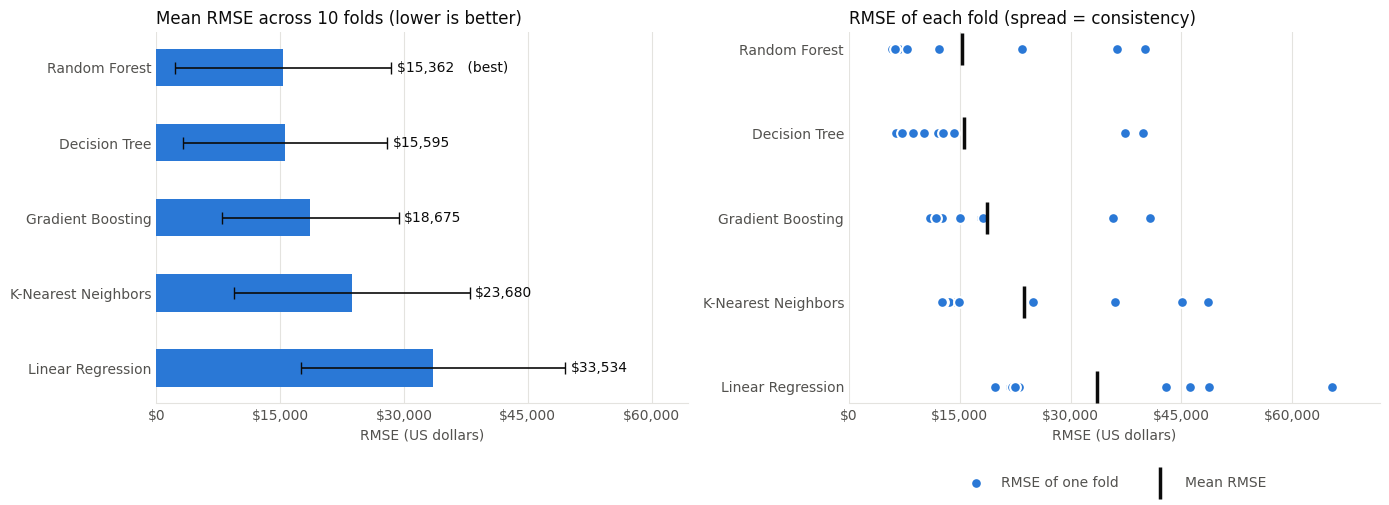

In [15]:
# Chart colours: one blue for the data, dark/grey text, light grid
BAR_COLOR = "#2a78d6"
TEXT_COLOR = "#0b0b0b"
MUTED_TEXT = "#52514e"
GRID_COLOR = "#e4e3df"
dollars = FuncFormatter(lambda value, _: f"${value:,.0f}")

def style_axis(ax):
    for side in ["top", "right", "left"]:
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(GRID_COLOR)
    ax.tick_params(colors=MUTED_TEXT, length=0)
    ax.xaxis.set_major_formatter(dollars)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
    ax.set_axisbelow(True)

order = summary.index.tolist()            # best algorithm first
positions = np.arange(len(order))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.2))

# ---- Chart 1: mean RMSE with +/- 1 std ----
means = summary["Mean RMSE ($)"]
stds = summary["Std RMSE ($)"]
ax1.barh(positions, means, height=0.5, color=BAR_COLOR,
         xerr=stds, error_kw=dict(ecolor=TEXT_COLOR, elinewidth=1.2, capsize=4))
for i, name in enumerate(order):
    label = f"${means[name]:,.0f}" + ("   (best)" if i == 0 else "")
    ax1.text(means[name] + stds[name] + means.max() * 0.02, i, label,
             va="center", color=TEXT_COLOR, fontsize=10)
ax1.set_yticks(positions, order, color=TEXT_COLOR)
ax1.invert_yaxis()
ax1.set_xlim(0, (means + stds).max() * 1.3)
style_axis(ax1)
ax1.set_title("Mean RMSE across 10 folds (lower is better)", loc="left", color=TEXT_COLOR, fontsize=12)
ax1.set_xlabel("RMSE (US dollars)", color=MUTED_TEXT)

# ---- Chart 2: RMSE of every fold ----
for i, name in enumerate(order):
    ax2.scatter(per_fold_table[name], np.full(K, i), s=60, color=BAR_COLOR,
                edgecolor="white", linewidth=1.5, zorder=3,
                label="RMSE of one fold" if i == 0 else None)
    ax2.scatter(means[name], i, marker="|", s=500, color=TEXT_COLOR, linewidth=2.5, zorder=4,
                label="Mean RMSE" if i == 0 else None)
ax2.set_yticks(positions, order, color=TEXT_COLOR)
ax2.invert_yaxis()
ax2.set_xlim(0, per_fold_table.values.max() * 1.1)
style_axis(ax2)
ax2.set_title("RMSE of each fold (spread = consistency)", loc="left", color=TEXT_COLOR, fontsize=12)
ax2.set_xlabel("RMSE (US dollars)", color=MUTED_TEXT)
ax2.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2, labelcolor=MUTED_TEXT)

plt.tight_layout()
plt.show()

## Step 9.4: Observations

> The numbers below come from our run. If your library versions are different, your numbers may differ slightly, but the overall pattern should be the same.

1. **Random Forest has the lowest mean RMSE (≈ $15,400)**, but **Decision Tree is almost identical (≈ $15,600)**. The difference (≈ $230) is tiny compared with their standard deviation (≈ $12,000 – $13,000), so in practice the two are **tied**.
2. **Tree-based algorithms clearly win.** Random Forest, Decision Tree and Gradient Boosting all beat KNN (≈ $23,700) and especially Linear Regression (≈ $33,500). Car prices are **not linear** in the features: luxury and exotic cars cost far more than a straight-line formula predicts.
3. **A few folds dominate the error.** Fold 2 contains the most expensive car in the dataset (**≈ $2,066,000**), and Linear Regression's RMSE there jumps to ≈ $65,300. Folds 6 and 10 (with cars of $1.4 million and $1.5 million) give an RMSE of ≈ $36,000 – $49,000 for *every* algorithm. On the remaining folds, Random Forest's RMSE is often only ≈ $6,000 – $8,000.
4. **This shows the effect of RMSE squaring large errors** (Step 3.1): for an ordinary car the typical error is much smaller than the mean RMSE suggests.
5. **Accuracy vs. speed:** Random Forest is by far the slowest algorithm (it trains 1,000 trees in total), while Decision Tree is about **10× faster** with almost the same RMSE. In a real project this trade-off matters.
6. **10 folds give a more reliable comparison** than the 3 folds on 100 cars: each algorithm is tested 10 times on about 1,120 cars, instead of 3 times on about 33 cars.

# Step 10: Train the Final Model
## Step 10.1: Select the Best Algorithm

**Cross validation is used to *choose* an algorithm, not to produce the final model.** The 10 models built during cross validation were only used to measure performance and are now thrown away.

We select the algorithm with the **lowest mean RMSE** from the summary table.

In [16]:
best_algorithm_name = summary.index[0]
best_mean_rmse = summary.loc[best_algorithm_name, "Mean RMSE ($)"]
best_std_rmse = summary.loc[best_algorithm_name, "Std RMSE ($)"]

print(f"Best algorithm : {best_algorithm_name}")
print(f"Expected RMSE  : ${best_mean_rmse:,.2f} (+/- ${best_std_rmse:,.2f})")

Best algorithm : Random Forest
Expected RMSE  : $15,361.85 (+/- $13,116.01)


## Step 10.2: Train the Best Algorithm on All the Data

Now that we know which algorithm works best, we train it on **all cars**. There is no separate test set here, because the cross-validation RMSE from Step 9 is already our estimate of how well this model will perform on new, unseen cars.

In [17]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", algorithms[best_algorithm_name]),
])

final_model.fit(X, y)

print(f"Final {best_algorithm_name} model trained on {len(X):,} cars.")

Final Random Forest model trained on 11,199 cars.


## Step 10.3: Save the Trained Model

The saved file contains the **whole pipeline** (imputer, scaler, one-hot encoder **and** the algorithm), so it can predict directly from raw car specifications.

To download the model file to your computer in Colab, set `DOWNLOAD_MODEL = True` and run the cell again, or use the **Files** panel (folder icon) on the left.

In [18]:
MODEL_FILE = "car_price_model_full_dataset.pkl"
DOWNLOAD_MODEL = False

with open(MODEL_FILE, "wb") as f:
    pickle.dump(final_model, f)

print(f"Trained model saved as '{MODEL_FILE}'")

if IN_COLAB and DOWNLOAD_MODEL:
    files.download(MODEL_FILE)

Trained model saved as 'car_price_model_full_dataset.pkl'


# Step 11: Execute the Application Phase
## Step 11.1: Take Input from User

By default the notebook uses the example car below, so that **Run all** works without stopping. To type in your own car, set `USE_INTERACTIVE_INPUT = True` and run the cell again.

In [19]:
USE_INTERACTIVE_INPUT = False

example_car = {
    "Engine HP": 300,
    "Year": 2015,
    "Engine Cylinders": 6,
    "city mpg": 19,
    "highway MPG": 27,
    "Popularity": 1385,
    "Market Category": "Luxury",
    "Vehicle Style": "Sedan",
}

def get_car_input():
    print("Enter Car Specifications (ranges seen in the data are shown):")
    print(f"  Engine HP       : {X['Engine HP'].min():.0f} - {X['Engine HP'].max():.0f}")
    print(f"  Year            : {X['Year'].min()} - {X['Year'].max()}")
    print(f"  Engine Cylinders: {X['Engine Cylinders'].min():.0f} - {X['Engine Cylinders'].max():.0f}")
    print(f"  City MPG        : {X['city mpg'].min()} - {X['city mpg'].max()}")
    print(f"  Highway MPG     : {X['highway MPG'].min()} - {X['highway MPG'].max()}")
    print(f"  Popularity      : {X['Popularity'].min()} - {X['Popularity'].max()}")

    car = {
        "Engine HP": float(input("Engine HP: ")),
        "Year": int(input("Year: ")),
        "Engine Cylinders": float(input("Engine Cylinders: ")),
        "city mpg": int(input("City MPG: ")),
        "highway MPG": int(input("Highway MPG: ")),
        "Popularity": int(input("Popularity: ")),
    }
    print("\nMost common Market Categories:", X["Market Category"].value_counts().index[:10].tolist())
    car["Market Category"] = input("Market Category: ").strip()
    print("\nAvailable Vehicle Styles:", sorted(X["Vehicle Style"].unique()))
    car["Vehicle Style"] = input("Vehicle Style: ").strip()
    return car

user_input = get_car_input() if USE_INTERACTIVE_INPUT else example_car

print("Car specifications:")
for feature, value in user_input.items():
    print(f"  {feature:<17}: {value}")

Car specifications:
  Engine HP        : 300
  Year             : 2015
  Engine Cylinders : 6
  city mpg         : 19
  highway MPG      : 27
  Popularity       : 1385
  Market Category  : Luxury
  Vehicle Style    : Sedan


## Step 11.2: Convert User Input into Feature Vector

The feature vector must have **exactly the same columns, in the same order,** as the training data. There is no need to encode it manually: the saved pipeline scales and one-hot encodes it automatically.

In [20]:
feature_vector = pd.DataFrame([user_input])[numeric_features + categorical_features]
feature_vector

,Engine HP,Year,Engine Cylinders,city mpg,highway MPG,Popularity,Market Category,Vehicle Style
0,300,2015,6,19,27,1385,Luxury,Sedan


## Step 11.3: Load the Saved Model

In [21]:
with open(MODEL_FILE, "rb") as f:
    loaded_model = pickle.load(f)

print(f"Model loaded from '{MODEL_FILE}': {loaded_model.named_steps['regressor'].__class__.__name__}")

Model loaded from 'car_price_model_full_dataset.pkl': RandomForestRegressor


## Step 11.4: Model Prediction

Apply the model to the feature vector of the unseen car and return the prediction to the user.

In [22]:
predicted_price = loaded_model.predict(feature_vector)[0]

print(f"Predicted Price (MSRP): ${predicted_price:,.2f}")
print(f"Typical error (cross-validation RMSE of {best_algorithm_name}): about ${best_mean_rmse:,.0f}")

Predicted Price (MSRP): $50,069.06
Typical error (cross-validation RMSE of Random Forest): about $15,362


# Step 12: Execute the Feedback Phase

After deployment, feedback from users and domain experts (e.g. car dealers) is used to improve the model. Potential improvements for this system:

1. **Add more features**: *Make* (brand), *Transmission Type*, *Driven Wheels* and *Vehicle Size* are already in the dataset and strongly affect price.
2. **Tune hyper-parameters**: e.g. the number of neighbours in KNN, or the depth and number of trees in Random Forest. Use cross validation (`GridSearchCV`) to choose them.
3. **Handle very expensive cars**: train a separate model for exotic/luxury cars, or report an error measure that is less sensitive to outliers (e.g. MAE) alongside RMSE.
4. **Collect more recent data**: the newest cars in the dataset are from 2017.

# Conclusion

In this notebook we compared **5 regression algorithms** on the **full car price dataset (11,199 unique cars)** using **10-fold cross validation** and **RMSE**.

- **Random Forest** achieved the lowest mean RMSE (≈ $15,400), with **Decision Tree** a very close second. Random Forest was trained on all the cars, saved, and used to predict the price of a new car.
- **Linear Regression performed worst**, because car prices have a strongly non-linear relationship with the features.
- The RMSE is strongly affected by a few very expensive cars. For typical cars, the errors are much smaller.

### Comparison With 100 Instances (Companion Notebook)

| Algorithm | Mean RMSE – 100 cars, 3-fold | Mean RMSE – full data, 10-fold |
|---|---|---|
| Decision Tree | **$22,317** (rank 1) | $15,595 (rank 2) |
| Gradient Boosting | $25,122 (rank 2) | $18,675 (rank 3) |
| Random Forest | $30,100 (rank 3) | **$15,362** (rank 1) |
| K-Nearest Neighbors | $34,584 (rank 4) | $23,680 (rank 4) |
| Linear Regression | $40,466 (rank 5) | $33,534 (rank 5) |

With the full dataset, **every algorithm's error drops**, and Random Forest, which needs lots of data to build many diverse trees, moves from **3rd place to 1st**. The lesson: **more data gives both better models and more trustworthy comparisons.**